# Duration DiD: absorbing individual outcomes

DurationDiD estimates how intervention changes cumulative absorption in a fixed
population observed at equally spaced dates. Positive effects mean more people
have experienced the event. The headline averages effects across the declared
post-periods, including people already absorbed at baseline in the population.

This example constructs complete histories with illustrative survivor counts.
It is not an empirical application or author-software replication. Identification
requires common dynamics (CD) or proportional untreated hazards (PH), no anticipation,
unaffected controls and common timing. These are hazard restrictions, not parallel
trends in the mean binary outcome. Inference additionally assumes independent people.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from diff_diff import DurationDiD, DiagnosticReport, BusinessReport, plot_event_study

rows = []
for group, counts in enumerate(([96, 80, 64, 48, 32, 16], [90, 75, 60, 45, 20, 8])):
    for person in range(400):
        for date, survivors in enumerate(counts):
            rows.append((400 * group + person, date, group, int(person >= 4 * survivors)))
panel = pd.DataFrame(rows, columns=["person", "date", "group", "absorbed"])
# Complete fixed populations, including baseline-absorbed people.
assert not panel.duplicated(["person", "date"]).any()
assert panel.groupby("person").size().eq(6).all()
panel.groupby(["group", "date"])["absorbed"].mean().unstack("group")

group,0,1
date,,
0,0.04,0.10
1,0.20,0.25
2,0.36,0.40
3,0.52,0.55
4,0.68,0.80
5,0.84,0.92


## Fit the common-dynamics specification

`group` is fixed membership; `post_periods=[4, 5]` supplies intervention timing.
The default calibration uses eligible dates after baseline and before intervention.
Calibration never changes the diagnostic window. The CD coefficient is a hazard
gap per normalized observation interval. These fits use a reproducible pooled
individual bootstrap with 199 draws; production defaults request 1,000 draws.

In [2]:
cd = DurationDiD(n_bootstrap=199, seed=33).fit(
    panel, "absorbed", "group", "person", "date", post_periods=[4, 5]
)
np.testing.assert_allclose(cd.effects["att"], [0.10, 0.07])
print(cd.summary())
cd.to_dataframe()

DurationDiD (common_dynamics)
Coefficient (hazard gap per normalized observation interval): 5.85951e-17
Mean cumulative absorption ATT: 0.085; SE: 0.0238052
95% CI: (0.041743657151780106, 0.12825634284821985); p-value: 0
Estimation: ok; inference: {'pointwise': 'available', 'simultaneous': 'available', 'simple': 'available'}
Pooled individual bootstrap: 199/199 valid effect draws
DurationDiD hazard pretest (common_dynamics)
95% simultaneous bands; not rejected
Statistic: 1.5609e-15; p-value: 1
Bootstrap draws: 199/199 valid (199 requested)
Non-rejection does not establish identification or adequate power.


,event_time,att,se,t_stat,p_value,conf_int_lower,conf_int_upper,cband_lower,cband_upper,n,df,is_reference,estimand
0,-1,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,att
1,0,0.10,0.027998,3.571701,0.0,0.044976,0.155024,0.040265,0.159735,400.0,NaN,False,att
2,1,0.07,0.023836,2.936731,0.0,0.023232,0.116768,0.019144,0.120856,400.0,NaN,False,att


## Inspect survival and effect paths

Counterfactual survival is the survival that treated people would have had without
intervention under the selected hazard restriction. Invalid probabilities or
increasing counterfactual survival suppress canonical causal estimates; raw
extrapolations remain inspectable. Zero factual treated post-survival is valid.
The effect plot contains a reference and post-date effects, not hazard contrasts
masquerading as pre-treatment outcome effects.

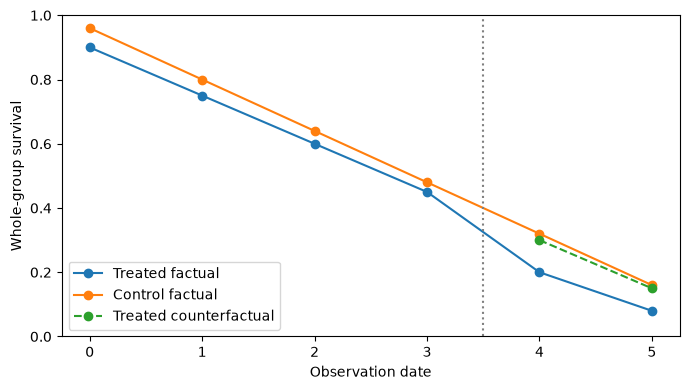

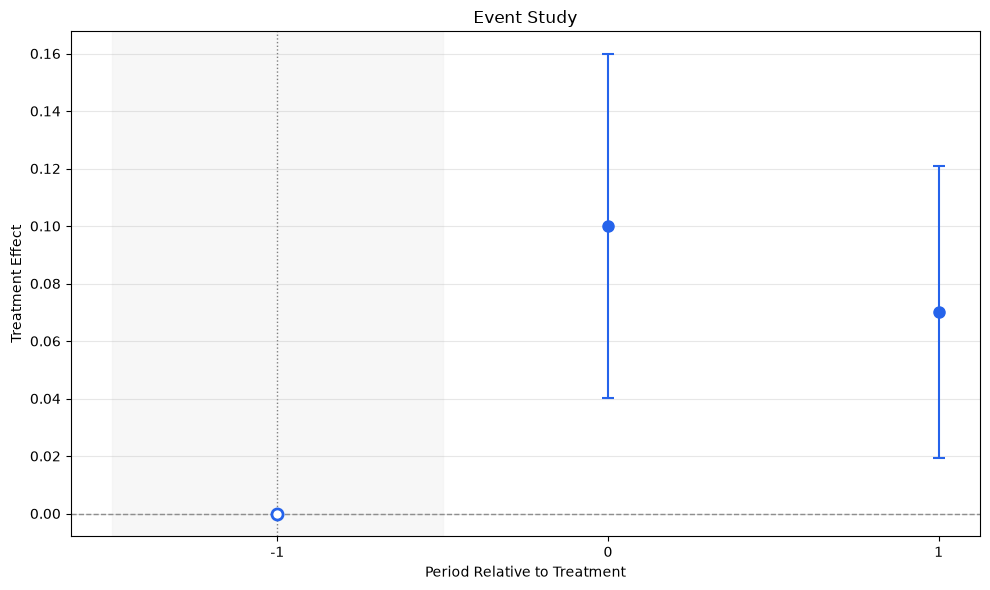

In [3]:
survival = cd.to_dataframe("survival")
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(survival.period, survival.treated_survival, "o-", label="Treated factual")
ax.plot(survival.period, survival.control_survival, "o-", label="Control factual")
ax.plot(survival.period, survival.raw_counterfactual_survival, "o--", label="Treated counterfactual")
ax.axvline(3.5, color="gray", linestyle=":")
ax.set(xlabel="Observation date", ylabel="Whole-group survival", ylim=(0, 1))
ax.legend()
plt.tight_layout()
plt.show()
plot_event_study(cd.aggregate("event_study"), show=False)
plt.show()

## Stored hazard pretest and proportional hazards

The Appendix B fixed-anchor pretest compares interior pre-date hazard gaps or
ratios with the last untreated anchor. Its simultaneous family excludes baseline
and anchor. Three pre-dates are necessary, and missing support, failed diagnostic
draws or zero SE make the entire pretest unavailable (`reject=None`). Non-rejection
does not establish identification or adequate power.

PH estimates a weighted mean of cumulative-hazard ratios. Its coefficient is
dimensionless. Comparing CD and PH is a specification assessment under different
hazard restrictions; it is not an automatic selection rule.

In [4]:
diagnostic = cd.pretrend_test()  # Owned copy of the stored Diagnostic; no refit.
print(diagnostic.summary())
diagnostic.to_dataframe()

DurationDiD hazard pretest (common_dynamics)
95% simultaneous bands; not rejected
Statistic: 1.5609e-15; p-value: 1
Bootstrap draws: 199/199 valid (199 requested)
Non-rejection does not establish identification or adequate power.


,period,elapsed_time,contrast,se,cband_lower,cband_upper,status,reason
0,1,1.0,4.625929e-17,0.029636,-0.066851,0.066851,available,None
1,2,2.0,1.850372e-17,0.020149,-0.045450,0.045450,available,None


In [5]:
ph = DurationDiD(method="proportional_hazards", n_bootstrap=199, seed=33).fit(
    panel, "absorbed", "group", "person", "date", post_periods=[4, 5],
    fit_periods=[1, 2, 3], time_weights={1: 1, 2: 1, 3: 1},
)
pd.DataFrame([
    {"method": r.method, "coefficient": r.coefficient, "att": r.att, "se": r.se,
     "valid_effect_draws": r.n_bootstrap_valid, "hazard_test": r.pretrend_results.status}
    for r in (cd, ph)
])

,method,coefficient,att,se,valid_effect_draws,hazard_test
0,common_dynamics,5.859510e-17,0.085,0.023805,199,available
1,proportional_hazards,1.000000e+00,0.085,0.031248,199,available


## Report availability honestly

Exactly B pooled history draws are attempted without retries or stratification.
Any failed draw disables inference for its family; successful draws are not
filtered into a new inferential distribution. Effect and diagnostic families
have independent availability. Inspect survivor/exit support and failure records.

DiagnosticReport extracts the stored hazard test without raw data or refitting.
Its outer native status describes extraction, and the nested status describes
statistical availability. BusinessReport preserves fitted confidence levels and
keeps fit-level validity caveats visible when automatic diagnostics are disabled.

In [6]:
native = DiagnosticReport(cd).to_dict()["estimator_native_diagnostics"]
assert native["pretrend_test"] == diagnostic.to_dict()
print("Effect inference:", native["inference_status"])
print("Hazard pretest:", native["pretrend_test"]["status"])
print(BusinessReport(cd, outcome_label="Cumulative absorption").summary())
cd.bootstrap_failures

Effect inference: {'pointwise': 'available', 'simultaneous': 'available', 'simple': 'available'}
Hazard pretest: available
The fixed-anchor hazard pretest does not reject at the 95% simultaneous confidence level (p=1). Non-rejection does not establish identification or adequate power. The treatment increased Cumulative absorption by 0.085 (95% CI: 0.0417 to 0.128). Target parameter: Mean cumulative absorption ATT. Statistically, the direction of the effect is strongly supported by the data. Sample: 4,800 observations (400 treated, 400 control).


,draw,family,period,reason


## Scope and sources

Only complete balanced individual panels with two groups and common treatment
timing are supported. Covariates, staggered adoption, censoring/dropout, repeated
cross-sections, survey weights and higher-level clustering require extensions.
`time_weights` calibrates dates and does not provide survey weighting. Do not
manufacture complete histories by filling missing outcomes or dropping people.
Generic HonestDiD, outcome parallel-trends and cluster-bootstrap workflows do not
apply to this estimator.

- Deaner and Ku (2026), [Causal Duration Analysis with Diff-in-Diff](https://arxiv.org/abs/2405.05220v2).
- [DurationDiD API](../api/duration_did.rst).
- Dated methodology review: `docs/methodology/papers/deaner-ku-2026-review.md` and
  [implementation Registry](../methodology/REGISTRY.md).
